In [2]:
import sys
sys.path.append("../")
import opendssdirect as dss
import yadi.hc.model.vc as dss_vc_hc

In [3]:
import numpy as np
import opendssdirect as dss
import matplotlib.pyplot as plt
import seaborn as sns
import yadi.dss.model as dss_model
import yadi.dss.sensitivity as dss_sens
import yadi.dss.qsts as dss_qsts

In [4]:
#Setup plot aesthetics
import matplotlib
%matplotlib inline
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb}')
sns.set_theme(context='paper',style='ticks')

In [49]:
cktfile = "./../test_cases/13Bus/IEEE13Nodeckt.dss"
sens = dss_sens.DSS_Sensitivities(cktfile,verbose=False)
#Get the taylor coefficients
dvdp = sens.get_svp()
dvdq = sens.get_svq()

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt


In [50]:
dss.Text.Command('Redirect ./../test_cases/13Bus/IEEE13Nodeckt.dss')
dss.Text.Command("solve")
vph_base = dss.Circuit.AllBusMagPu()
print(vph_base)

[0.9999735651307984, 0.9999938111322225, 0.9999501157727909, 0.9999107892484708, 0.9999708399151168, 0.9999311121233335, 1.056033142623909, 1.0373856722265078, 1.0560497112605165, 1.0112995703537142, 1.0270163778302073, 1.0015457164649626, 0.9871581291246257, 1.008418390771125, 0.9824543135502444, 0.9827945900526428, 1.0402751459827904, 0.9648858069601736, 1.0197281538564085, 1.0022791051369995, 1.0180121613192226, 1.0002448428091992, 0.9648857995132878, 0.9827945806860713, 1.0402751448440755, 0.9762702055782954, 1.0426315548533853, 0.9629519977913329, 0.9608397666651269, 0.9753314209556365, 1.004023274234643, 1.031869686414173, 0.98974996026328, 1.0143420476420513, 1.0289439438633898, 1.004193367052126, 0.9827946025916482, 1.040275160824878, 0.9648858207496351, 0.9808711491163657, 0.962855736552005]


In [51]:
svp,svq = (dvdp["matrix"]*100)/120,(dvdq["matrix"]*100)/120
print(np.diag(svp))
svp,svq = svp[9:,9:],svq[9:,9:]
svp,svq = svp[6:,6:],svq[6:,6:]
vbase_study = vph_base[9:]
vbase_study = vbase_study[6:]
n_study = svp.shape[0]
p_range = np.array([i for i in np.arange(start=1,stop=2000,step=0.1)])
vplus = np.zeros((len(p_range),n_study))
for i in range(n_study):
    vhat_i = [svp[:,i]*p_i for p_i in p_range]
    vhat_ii = [vi[i] for vi in vhat_i]
    vplus_ii = [vbase_study[i] + vii for vii in vhat_ii]
    vplus[:,i] = vplus_ii


[5.38097687e-04 5.38153411e-04 5.38133201e-04 2.24780837e-08
 2.24758198e-08 2.24824065e-08 7.89387169e-08 7.48077792e-08
 7.89490092e-08 2.99737537e-05 2.88961755e-05 2.96739239e-05
 1.26996329e-07 1.25336370e-07 1.24584020e-07 4.43214875e-05
 3.98773285e-05 4.41268475e-05 3.62113099e-05 4.59980795e-05
 4.59169149e-05 4.41269041e-05 4.43215749e-05 5.54327142e-05
 5.08436012e-05 5.47893826e-05 6.40804931e-05 7.78030883e-05
 2.79042515e-05 2.60047237e-05 2.80385393e-05 2.03807806e-05
 1.93062516e-05 2.03488271e-05 5.26130082e-05 4.84239815e-05
 5.21468045e-05 3.63637278e-05 3.98772717e-05 5.35980235e-05
 5.40893120e-05]


array([4.43214875e-05, 3.98773285e-05, 4.41268475e-05, 3.62113099e-05,
       4.59980795e-05, 4.59169149e-05, 4.41269041e-05, 4.43215749e-05,
       5.54327142e-05, 5.08436012e-05, 5.47893826e-05, 6.40804931e-05,
       7.78030883e-05, 2.79042515e-05, 2.60047237e-05, 2.80385393e-05,
       2.03807806e-05, 1.93062516e-05, 2.03488271e-05, 5.26130082e-05,
       4.84239815e-05, 5.21468045e-05, 3.63637278e-05, 3.98772717e-05,
       5.35980235e-05, 5.40893120e-05])

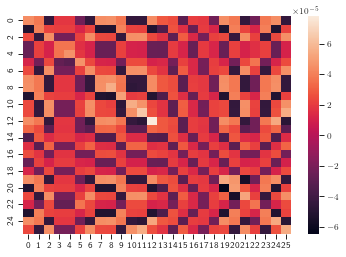

In [47]:
sns.heatmap(svp)
np.diag(svp)

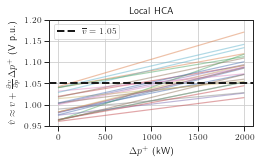

In [48]:
fig,ax= plt.subplots(figsize=(3.5,3.5/1.61828),constrained_layout=True)

ax.plot(p_range,vplus,alpha=0.5)
ax.axhline(1.05,ls='--',c='k',lw=2,label=r"$\overline{v} = 1.05$")
ax.grid()
#ax.set_xlim(0,2000)
ax.set_ylim(0.95,1.2)
ax.legend()
ax.set_xlabel("$\Delta p^{+}$ (kW)")
ax.set_ylabel(r"$\hat{v} \approx v + \frac{\partial v}{\partial p} \Delta p^{+}$ (V p.u.)")
ax.set_title("Local HCA")
plt.savefig("local_hca_v2.pdf",dpi=400)
#plt.savefig("local_hca.png",dpi=400)

In [ ]:
plt.plot(v_hat_1[])

In [31]:
1e6

1000000.0

In [3]:
redirects = ["./../test_cases/13Bus/IEEE13Nodeckt.dss"]
vchc = dss_vc_hc.DSS_VC_HCA(redirects)
hc = vchc.get_iterative_hc()

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt
DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt
DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeckt.dss
DSS Compiled Circuit: ieee13nodeckt

DSS Running file: ./../test_cases/13Bus/IEEE13Nodeck

In [4]:
hc

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [18]:
vph_base = dss.Circuit.AllBusMagPu()

In [19]:
sub_overvoltage_idx = [i for i in range(len(vph_base)) if vph_base[i]<1.05]

In [36]:
import numpy as np
np.any(np.asarray(vph_base) > 1.05)

True